# Algorithmic Trading in Python
---

**Proposal:**
Develop a strategy of RSI + Momentum to determine buying and selling signals + Efficient frontier line for better operations

Google Sheets/ Excel:
https://docs.google.com/spreadsheets/d/1UTc6IPuWEgLhRVwyranhKZWKuQd0B2qe/edit?usp=sharing&ouid=109338790302073248684&rtpof=true&sd=true

# Data Import

In [ ]:
# Install required libraries
# Run this cell first if packages are not yet installed
!pip install yfinance bt --quiet
!pip install PyPortfolioOpt --quiet  # Required for Efficient Frontier section
                                     # If this fails: pip install PyPortfolioOpt --upgrade

In [ ]:
#First it is necessary to import the libraries
import bt
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import plotting
from pypfopt import HRPOpt
import seaborn as sb

#Output Production

In [ ]:
# Define date range
start_date = '2012-05-18'
end_date   = '2023-01-01'

# Define universe (always lowercase for bt)
tickers = ['aapl', 'nvda', 'msft', 'tsla', 'nflx', 'meta']

# Fetch price data and SPY benchmark
data = bt.get(tickers, start=start_date, end=end_date)
spy  = bt.get('spy',   start=start_date, end=end_date)

print(data.head())

# Define train / test periods
train_start = '2012-05-18'
train_end   = '2019-12-31'
test_start  = '2020-01-01'
test_end    = '2023-01-01'

train_data = data.loc[train_start:train_end]
test_data  = data.loc[test_start:test_end]

print(f"Training data: {train_data.index[0].date()} → {train_data.index[-1].date()}")
print(f"Testing data : {test_data.index[0].date()}  → {test_data.index[-1].date()}")

                 aapl      nvda       msft      tsla       nflx       meta
Date                                                                      
2012-05-18  15.940146  0.276934  23.307404  1.837333   9.994286  38.050667
2012-05-21  16.868811  0.281749  23.689623  1.918000  10.248571  33.870373
2012-05-22  16.739279  0.278310  23.697578  2.053333   9.672857  30.854582
2012-05-23  17.147717  0.285187  23.179993  2.068000  10.272857  31.849892
2012-05-24  16.990231  0.277622  23.148136  2.018667  10.038571  32.875061
Training data from 2012-05-18 00:00:00 to 2019-12-31 00:00:00
Testing data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00


In [ ]:
#Define the momentum for first strategy

momentum_train = {}
momentum_test = {}

for ticker in tickers:
    # Training momentum
    momentum_train[ticker] = (train_data[ticker] / train_data[ticker].shift(126) - 1) * 100
    momentum_train[ticker] = momentum_train[ticker].dropna()

    # Testing momentum
    momentum_test[ticker] = (test_data[ticker] / test_data[ticker].shift(126) - 1) * 100
    momentum_test[ticker] = momentum_test[ticker].dropna()

#Defining the RSI
def rsi_calc(price, n=14):
    delta = price.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# --- RSI Calculation ---

rsi_train = rsi_calc(train_data)
rsi_test = rsi_calc(test_data)

# Drop NA rows for clean index alignment
rsi_train.dropna(inplace=True)
rsi_test.dropna(inplace=True)

# Print one value to check
print(f"Training RSI for AAPL:\n{rsi_train['aapl'].tail()}")
print(f"Testing Momentum for MSFT:\n{momentum_test['msft'].tail()}")

Training RSI for AAPL:
Date
2019-12-24    84.544844
2019-12-26    85.353338
2019-12-27    82.477072
2019-12-30    95.021795
2019-12-31    95.123552
Name: aapl, dtype: float64
Testing Momentum for MSFT:
Date
2022-12-23   -9.429987
2022-12-27   -7.153704
2022-12-28   -9.440493
2022-12-29   -5.695525
2022-12-30   -7.155265
Name: msft, dtype: float64


#Graph of Momentum and RSI

In [ ]:
"""
plot_momentum_rsi('ticker') for the ones gathered by data in steps prior to this one.
"""

def plot_momentum_rsi(ticker, rsi_df, momentum_dict, data_df, spy_df, start, end, title_suffix=''):
    # Subplot view
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # 1st plot: Momentum and Price
    ax1.plot(data_df[ticker].loc[start:end], label='Price', color='black')
    ax1.plot(momentum_dict[ticker].loc[start:end], label='Momentum (126d) in %', color='blue', linestyle='--')
    ax1.plot(spy_df[data_df[ticker].first_valid_index():end], label='spy', color='red', alpha=0.4, linestyle=':')
    ax1.set_title(f'{ticker} - Price & Momentum {title_suffix}')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # 2nd plot: RSI
    ax2.plot(rsi_df[ticker].loc[start:end], label='RSI', color='mediumpurple', alpha=0.6)
    ax2.axhline(30, color='rebeccapurple', linestyle='--', label='Oversold (30)')
    ax2.axhline(70, color='hotpink', linestyle='--', label='Overbought (70)')
    ax2.set_ylim(0, 100)
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

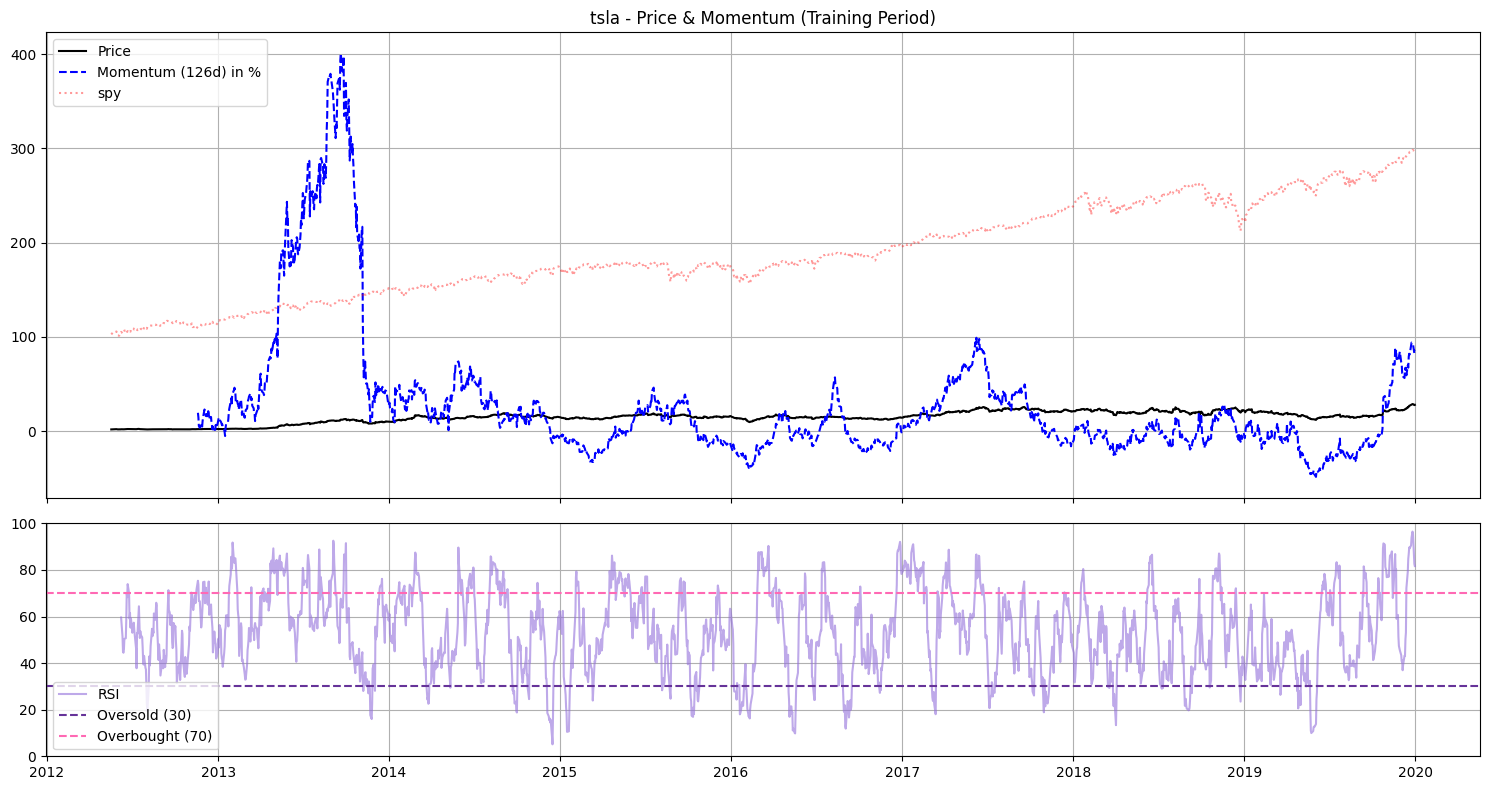

In [ ]:
# Interactive Plot for Momentum and RSI, just necessary to change the ticker in the function

# Visualize training data for TSLA

plot_momentum_rsi(
    ticker='tsla',
    rsi_df=rsi_train,
    momentum_dict=momentum_train,
    data_df=train_data,
    spy_df=spy,
    start='2012-05-18',
    end='2019-12-31',
    title_suffix='(Training Period)'
)

#Strategy Creation

Weight Creation Training Data

In [ ]:
# Weight construction — Training Period
# Note: momentum_train values are computed with .dropna(), so their index is shorter
# than train_data.index. We use .reindex(train_data.index).fillna(0) to realign
# them before building the weight matrix — without this, .loc[date] lookups fail.

# Align momentum and RSI to the full training index
momentum_df_train = pd.DataFrame(momentum_train).reindex(train_data.index).fillna(0)
rsi_df_train      = pd.DataFrame(rsi_train).reindex(train_data.index).fillna(50)

# Initialise weight matrix
target_weights_train = pd.DataFrame(0.0, index=train_data.index, columns=tickers)

# Buy: momentum above mean AND RSI below mean (oversold in an uptrend)
# Sell: momentum strongly negative AND RSI above 60 (overbought reversal)
buy_cond_train  = (momentum_df_train >= momentum_df_train.mean()) & (rsi_df_train < rsi_df_train.mean())
sell_cond_train = (momentum_df_train < (momentum_df_train.mean() * -1)) & (rsi_df_train > 60)

for date in train_data.index:
    buys_today  = buy_cond_train.loc[date]
    sells_today = sell_cond_train.loc[date]
    selected = [t for t in tickers if buys_today[t] and not sells_today[t]]
    if selected:
        weight = 1.0 / len(selected)
        for t in selected:
            target_weights_train.loc[date, t] = weight

print("Training Buy signals:");  print(buy_cond_train.sum())
print("Training Sell signals:"); print(sell_cond_train.sum())

Training Buy signals:
aapl    442
nvda    248
msft    491
tsla    163
nflx    222
meta    329
dtype: int64
Training Sell signals:
aapl    98
nvda    42
msft     0
tsla    18
nflx     0
meta    23
dtype: int64


Weight Creation Test Data

In [ ]:
# Create DataFrames from train signals

momentum_df_test = pd.DataFrame(momentum_test).reindex(test_data.index).fillna(0)
rsi_df_test = pd.DataFrame(rsi_test).reindex(test_data.index).fillna(50)

target_weights_test = pd.DataFrame(0.0, index=test_data.index, columns=tickers)

buy_cond_test = (momentum_df_test >= momentum_df_test.mean()) & (rsi_df_test < rsi_df_test.mean())
sell_cond_test = (momentum_df_test < (momentum_df_test.mean() * -1)) & (rsi_df_test > 60)

for date in test_data.index:
    buys_today = buy_cond_test.loc[date]
    sells_today = sell_cond_test.loc[date]
    selected = [ticker for ticker in tickers if buys_today[ticker] and not sells_today[ticker]]
    if selected:
        magnitude = 1.0 / len(selected)
        for ticker in selected:
            target_weights_test.loc[date, ticker] = magnitude

print("Testing Buy signals:")
print(buy_cond_test.sum())
print("Testing Sell signals:")
print(sell_cond_test.sum())

Testing Buy signals:
aapl    105
nvda    154
msft    151
tsla    122
nflx    160
meta    173
dtype: int64
Testing Sell signals:
aapl     8
nvda    18
msft    14
tsla     0
nflx    47
meta    92
dtype: int64


**Code for Training Period Analysis**

In [ ]:
#To determine the RSI Filter

print("===== TRAINING PERIOD FILTER ANALYSIS =====")
print('RSI MEAN (Train):')
print(rsi_df_train.mean())

print('\nRSI MODE (Train):')
print(rsi_df_train.mode().iloc[0])  # mode() returns a DataFrame

print('\nRSI MEDIAN (Train):')
print(rsi_df_train.median())

print('\nRSI STD (Train):')
print(rsi_df_train.std())

print('\nMOMENTUM MEAN (Train):')
print(momentum_df_train.mean())

print('\nMOMENTUM MODE (Train):')
print(momentum_df_train.mode().iloc[0])

print('\nMOMENTUM MEDIAN (Train):')
print(momentum_df_train.median())

print('\nMOMENTUM STD (Train):')
print(momentum_df_train.std())

"""
Most data is in between the 50 treshold, meaning S&P500 are very stable firms with low STD
Therefore trigerring signals the closest to the mode is the most beneficial
Especially when the momentum of the trend is negative
"""

===== TRAINING PERIOD FILTER ANALYSIS =====
RSI MEAN (Train):
aapl    55.719551
nvda    55.985525
msft    56.632842
tsla    53.505368
nflx    54.867079
meta    54.619545
dtype: float64

RSI MODE (Train):
aapl    50.0
nvda    50.0
msft    50.0
tsla    50.0
nflx    50.0
meta    50.0
Name: 0, dtype: float64

RSI MEDIAN (Train):
aapl    55.414920
nvda    55.914153
msft    55.975192
tsla    53.225819
nflx    55.933993
meta    55.230788
dtype: float64

RSI STD (Train):
aapl    18.152859
nvda    16.781292
msft    15.004995
tsla    17.635704
nflx    17.906212
meta    15.721082
dtype: float64

MOMENTUM MEAN (Train):
aapl     9.197970
nvda    24.230643
msft    12.622183
tsla    26.734200
nflx    33.315846
meta    17.012211
dtype: float64

MOMENTUM MODE (Train):
aapl    0.0
nvda    0.0
msft    0.0
tsla    0.0
nflx    0.0
meta    0.0
Name: 0, dtype: float64

MOMENTUM MEDIAN (Train):
aapl    12.007377
nvda    17.116518
msft    14.752458
tsla     6.410034
nflx    22.389608
meta    12.551657
dtype: f

'\nMost data is in between the 50 treshold, meaning S&P500 are very stable firms with low STD\nTherefore trigerring signals the closest to the mode is the most beneficial\nEspecially when the momentum of the trend is negative\n'

Test Period Filter Statistics

In [ ]:
print("\n===== TESTING PERIOD FILTER ANALYSIS =====")
print('RSI MEAN (Test):')
print(rsi_df_test.mean())

print('\nRSI MODE (Test):')
print(rsi_df_test.mode().iloc[0])

print('\nRSI MEDIAN (Test):')
print(rsi_df_test.median())

print('\nRSI STD (Test):')
print(rsi_df_test.std())

print('\nMOMENTUM MEAN (Test):')
print(momentum_df_test.mean())

print('\nMOMENTUM MODE (Test):')
print(momentum_df_test.mode().iloc[0])

print('\nMOMENTUM MEDIAN (Test):')
print(momentum_df_test.median())

print('\nMOMENTUM STD (Test):')
print(momentum_df_test.std())


===== TESTING PERIOD FILTER ANALYSIS =====
RSI MEAN (Test):
aapl    53.973559
nvda    54.274699
msft    53.773237
tsla    53.659408
nflx    51.387043
meta    49.973077
dtype: float64

RSI MODE (Test):
aapl    50.0
nvda    50.0
msft    50.0
tsla    50.0
nflx    50.0
meta    50.0
Name: 0, dtype: float64

RSI MEDIAN (Test):
aapl    53.568913
nvda    53.282412
msft    53.200248
tsla    52.229575
nflx    51.248580
meta    50.000000
dtype: float64

RSI STD (Test):
aapl    16.377659
nvda    16.687159
msft    15.629925
tsla    18.268883
nflx    16.292335
meta    14.954369
dtype: float64

MOMENTUM MEAN (Test):
aapl    14.540547
nvda    21.300489
msft     8.212886
tsla    50.099331
nflx     0.151933
meta    -1.330948
dtype: float64

MOMENTUM MODE (Test):
aapl    0.0
nvda    0.0
msft    0.0
tsla    0.0
nflx    0.0
meta    0.0
Name: 0, dtype: float64

MOMENTUM MEDIAN (Test):
aapl     8.126297
nvda    12.953148
msft     8.138728
tsla    11.110117
nflx     0.000000
meta     0.000000
dtype: float64


<Axes: title={'center': 'Target Weights Based on RSI and Momentum (Training Period)'}, xlabel='Date'>

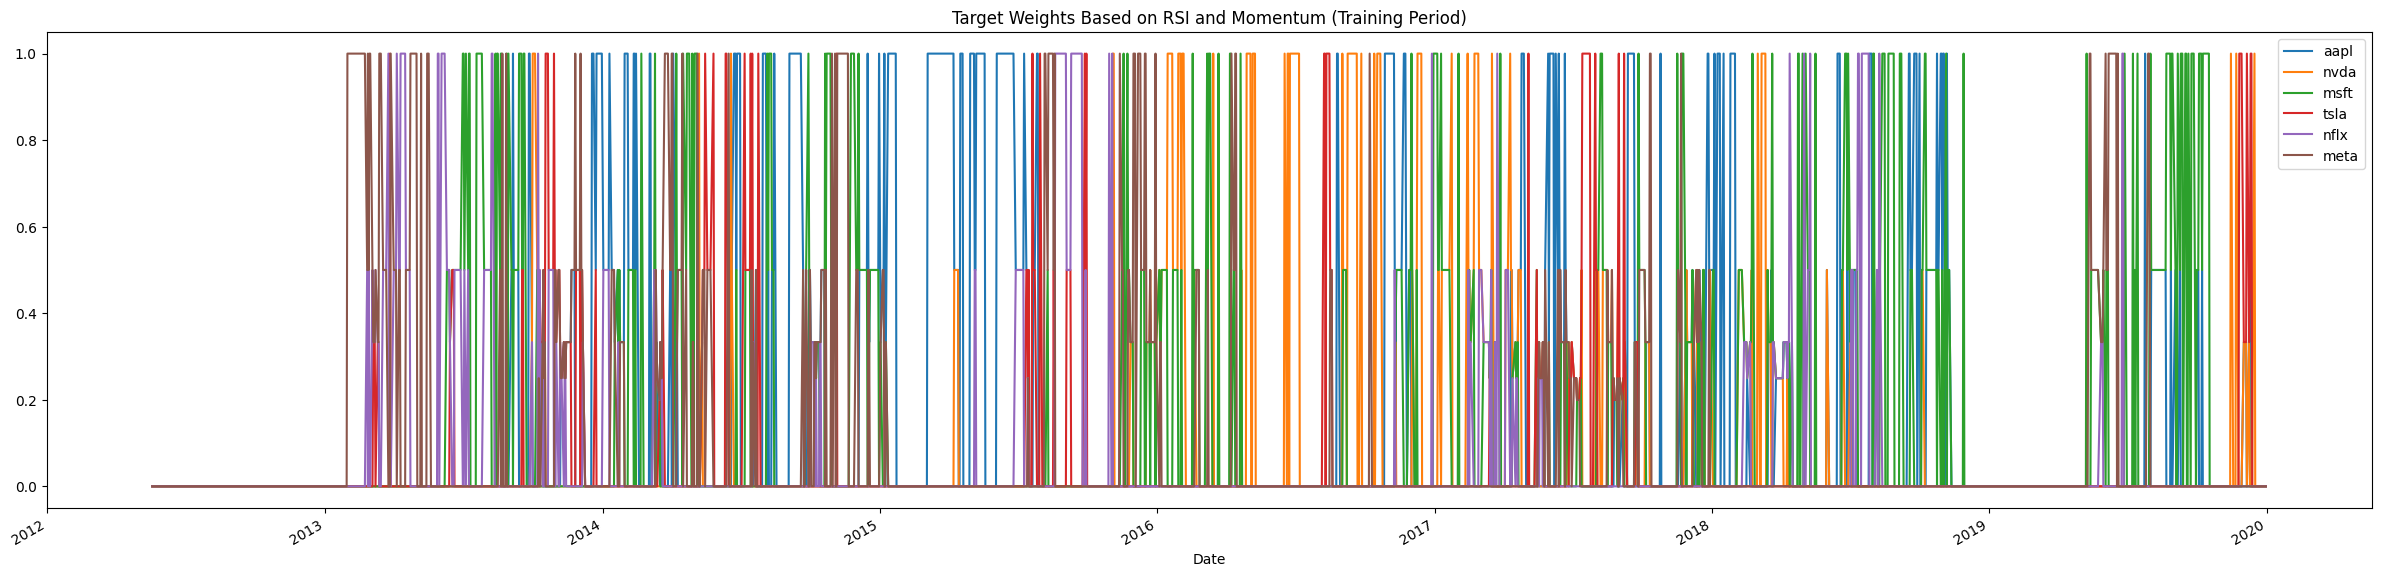

In [ ]:
target_weights_train.plot(
    figsize=(30, 7),
    title='Target Weights Based on RSI and Momentum (Training Period)'
)

Simulate Transaction Cost

In [ ]:
transaction_cost=0.005

class AdjustWeightsForTransactionCost(bt.Algo):
    def __init__(self, cost):
        super().__init__()
        self.cost = cost

    def __call__(self, target):
        # Only proceed if 'weights' exist in temp
        if 'target_weights_combo' not in target.temp:
            return True

Strategy Creation - Training Data

100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

Stat                 momentum_ris_train
-------------------  --------------------
Start                2012-05-17
End                  2019-12-31
Risk-free rate       0.00%

Total Return         387.13%
Daily Sharpe         0.98
Daily Sortino        1.59
CAGR                 23.09%
Max Drawdown         -25.09%
Calmar Ratio         0.92

MTD                  9.74%
3m                   20.11%
6m                   27.03%
YTD                  46.12%
1Y                   46.12%
3Y (ann.)            24.38%
5Y (ann.)            21.66%
10Y (ann.)           -
Since Incep. (ann.)  23.09%

Daily Sharpe         0.98
Daily Sortino        1.59
Daily Mean (ann.)    23.75%
Daily Vol (ann.)     24.27%
Daily Skew           0.54
Daily Kurt           12.27
Best Day             13.86%
Worst Day            -9.27%

Monthly Sharpe       0.98
Monthly Sortino      2.11
Monthly Mean (ann.)  23.90%
Monthly Vol (ann.)   24.29%
Monthly Skew         0.31
Monthly Kurt         0.48
Best Month           22.20%
Worst Mo

<Axes: title={'center': 'Training Period Strategy Performance'}>

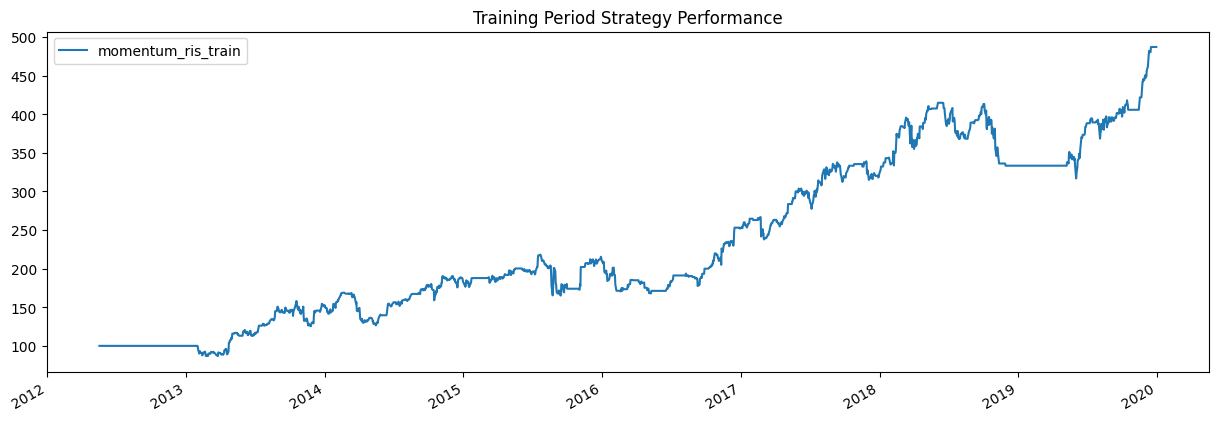

In [ ]:
# Strategy backtest — Training Period
momentum_ris_train = bt.Strategy('momentum_ris_train', [
    bt.algos.WeighTarget(target_weights_train),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

backtest_train = bt.Backtest(momentum_ris_train, train_data)
res_train      = bt.run(backtest_train)
res_train.display()

ax = res_train.plot(title='Training Period Strategy Performance')
plt.tight_layout()
plt.show()

Strategy Creation - Testing Data

100%|██████████| 1/1 [00:00<00:00,  2.86it/s]

Stat                 momentum_ris_test
-------------------  -------------------
Start                2020-01-01
End                  2022-12-30
Risk-free rate       0.00%

Total Return         26.46%
Daily Sharpe         0.41
Daily Sortino        0.62
CAGR                 8.15%
Max Drawdown         -28.95%
Calmar Ratio         0.28

MTD                  3.89%
3m                   11.09%
6m                   11.09%
YTD                  0.32%
1Y                   -0.77%
3Y (ann.)            8.15%
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  8.15%

Daily Sharpe         0.41
Daily Sortino        0.62
Daily Mean (ann.)    12.11%
Daily Vol (ann.)     29.21%
Daily Skew           -0.20
Daily Kurt           11.41
Best Day             11.61%
Worst Day            -14.25%

Monthly Sharpe       0.48
Monthly Sortino      0.86
Monthly Mean (ann.)  12.59%
Monthly Vol (ann.)   26.00%
Monthly Skew         0.31
Monthly Kurt         2.47
Best Month           24.81%
Worst Month       

<Axes: title={'center': 'Testing Period Strategy Performance'}>

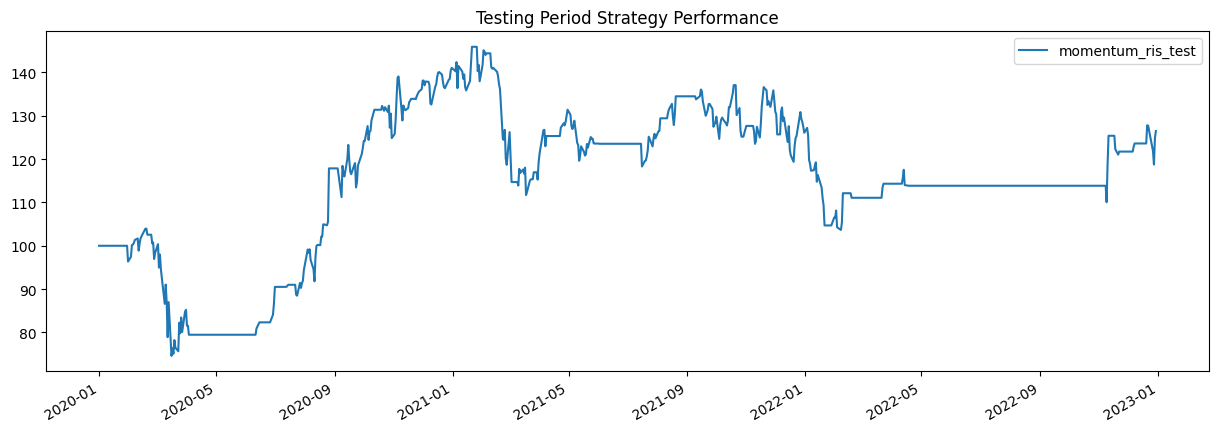

In [ ]:
# Strategy backtest — Testing Period
momentum_ris_test = bt.Strategy('momentum_ris_test', [
    bt.algos.WeighTarget(target_weights_test),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

backtest_test = bt.Backtest(momentum_ris_test, test_data)
res_test      = bt.run(backtest_test)
res_test.display()

ax = res_test.plot(title='Testing Period Strategy Performance')
plt.tight_layout()
plt.show()

Training Period Benchmark Strategy

100%|██████████| 1/1 [00:00<00:00,  4.64it/s]

Stat                 benchmark_train
-------------------  -----------------
Start                2012-05-17
End                  2019-12-31
Risk-free rate       0.00%

Total Return         1316.23%
Daily Sharpe         1.35
Daily Sortino        2.29
CAGR                 41.59%
Max Drawdown         -39.47%
Calmar Ratio         1.05

MTD                  8.31%
3m                   31.01%
6m                   16.30%
YTD                  40.02%
1Y                   40.02%
3Y (ann.)            32.22%
5Y (ann.)            33.59%
10Y (ann.)           -
Since Incep. (ann.)  41.59%

Daily Sharpe         1.35
Daily Sortino        2.29
Daily Mean (ann.)    39.04%
Daily Vol (ann.)     28.89%
Daily Skew           -0.07
Daily Kurt           2.20
Best Day             8.53%
Worst Day            -7.74%

Monthly Sharpe       1.39
Monthly Sortino      3.30
Monthly Mean (ann.)  39.68%
Monthly Vol (ann.)   28.57%
Monthly Skew         0.15
Monthly Kurt         -0.20
Best Month           25.20%
Worst Month  

<Axes: title={'center': 'Benchmark Strategy (Training Period)'}>

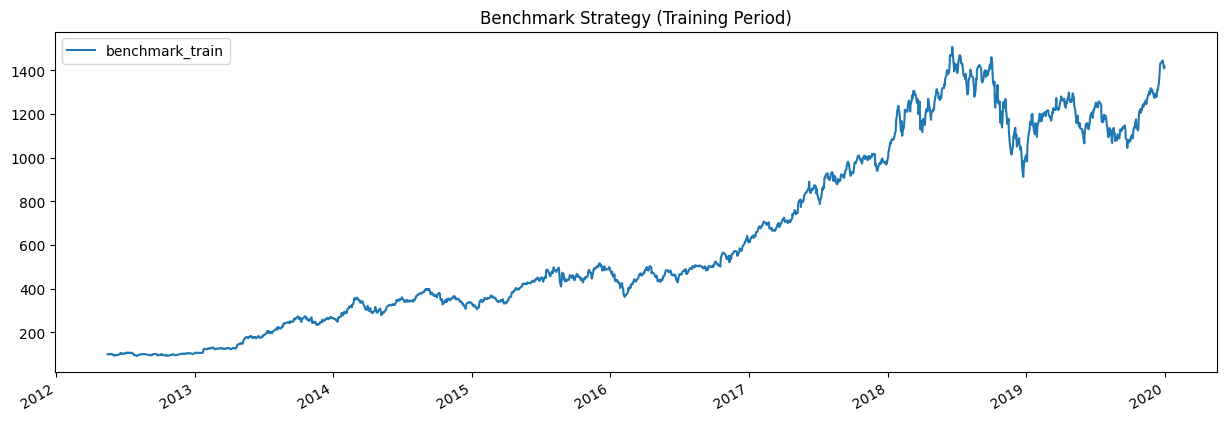

In [ ]:
'''
Show the opposite of the active strategy proposed by only having passive strategy
of holding the benchmark
'''

# Define the benchmark strategy for the training period
benchmark_strat_train = bt.Strategy('benchmark_train', [
    bt.algos.RunOnce(),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

# Run the backtest on training benchmark
benchmark_bt_train = bt.Backtest(benchmark_strat_train, train_data)

# Execute and display
res_benchmark_train = bt.run(benchmark_bt_train)
res_benchmark_train.display()
res_benchmark_train.plot(title='Benchmark Strategy (Training Period)')

Testing Period Benchmark Strategy

100%|██████████| 1/1 [00:00<00:00,  4.98it/s]

Stat                 benchmark_test
-------------------  ----------------
Start                2020-01-01
End                  2022-12-30
Risk-free rate       0.00%

Total Return         91.82%
Daily Sharpe         0.70
Daily Sortino        1.14
CAGR                 24.29%
Max Drawdown         -59.84%
Calmar Ratio         0.41

MTD                  -22.00%
3m                   -28.07%
6m                   -24.03%
YTD                  -54.25%
1Y                   -54.76%
3Y (ann.)            24.29%
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  24.29%

Daily Sharpe         0.70
Daily Sortino        1.14
Daily Mean (ann.)    32.35%
Daily Vol (ann.)     45.98%
Daily Skew           -0.32
Daily Kurt           1.81
Best Day             11.51%
Worst Day            -15.20%

Monthly Sharpe       0.63
Monthly Sortino      1.45
Monthly Mean (ann.)  29.47%
Monthly Vol (ann.)   46.99%
Monthly Skew         0.47
Monthly Kurt         -0.25
Best Month           35.05%
Worst Month   

<Axes: title={'center': 'Benchmark Strategy (Testing Period)'}>

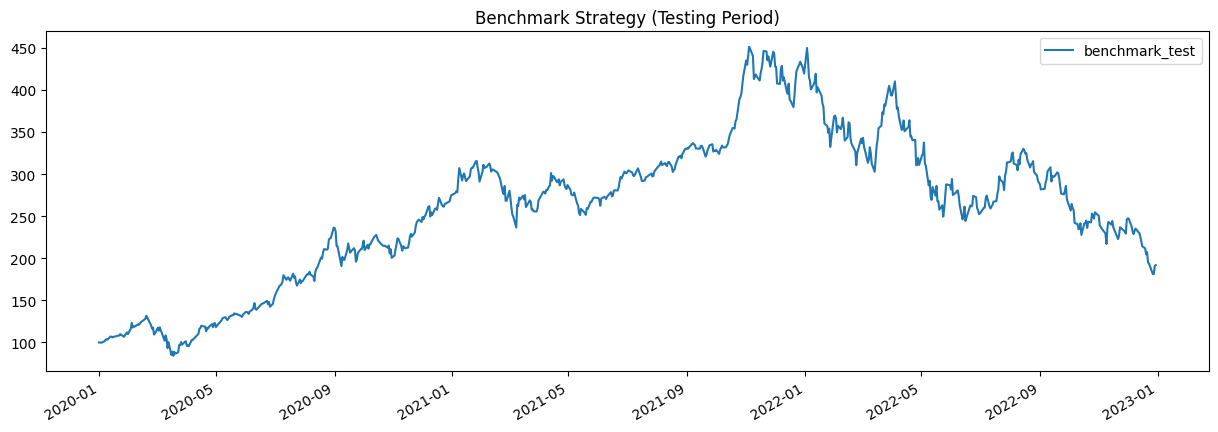

In [ ]:
# Define the benchmark strategy for the testing period
benchmark_strat_test = bt.Strategy('benchmark_test', [
    bt.algos.RunOnce(),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    AdjustWeightsForTransactionCost(transaction_cost),
    bt.algos.Rebalance()
])

# Run the backtest on testing benchmark
benchmark_bt_test = bt.Backtest(benchmark_strat_test, test_data)

# Execute and display
res_benchmark_test = bt.run(benchmark_bt_test)
res_benchmark_test.display()
res_benchmark_test.plot(title='Benchmark Strategy (Testing Period)')


Direct Comparison — Training Period

100%|██████████| 2/2 [00:00<00:00, 10512.04it/s]


Stat                 benchmark_train    momentum_ris_train
-------------------  -----------------  --------------------
Start                2012-05-17         2012-05-17
End                  2019-12-31         2019-12-31
Risk-free rate       0.00%              0.00%

Total Return         1316.23%           387.13%
Daily Sharpe         1.35               0.98
Daily Sortino        2.29               1.59
CAGR                 41.59%             23.09%
Max Drawdown         -39.47%            -25.09%
Calmar Ratio         1.05               0.92

MTD                  8.31%              9.74%
3m                   31.01%             20.11%
6m                   16.30%             27.03%
YTD                  40.02%             46.12%
1Y                   40.02%             46.12%
3Y (ann.)            32.22%             24.38%
5Y (ann.)            33.59%             21.66%
10Y (ann.)           -                  -
Since Incep. (ann.)  41.59%             23.09%

Daily Sharpe         1.35         

<Axes: title={'center': 'Training Period: Strategy vs Benchmark'}>

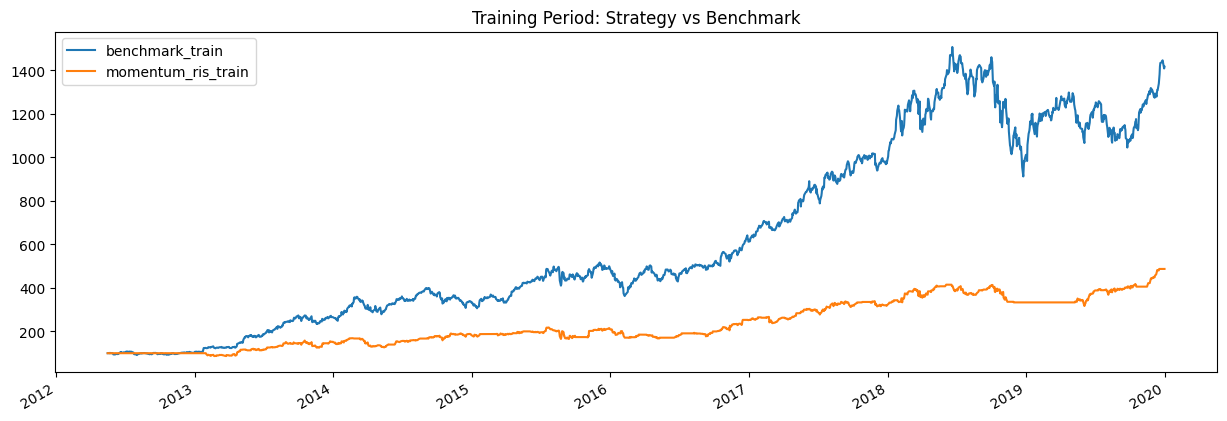

In [ ]:
# Direct comparison — Training Period: Strategy vs Benchmark vs SPY
res_train_comparison = bt.run(benchmark_bt_train, backtest_train)
res_train_comparison.display()

ax = res_train_comparison.plot(title='Training Period: Strategy vs Benchmark')

# Overlay SPY for market context
spy_train = spy.loc[train_start:train_end]
spy_norm  = spy_train / spy_train.iloc[0] * 100   # normalise to 100 (same base as bt)
ax.plot(spy_norm, label='SPY', color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
ax.legend()
plt.tight_layout()
plt.show()

Direct Comparison — Testing Period

100%|██████████| 2/2 [00:00<00:00, 22429.43it/s]

Stat                 benchmark_test    momentum_ris_test
-------------------  ----------------  -------------------
Start                2020-01-01        2020-01-01
End                  2022-12-30        2022-12-30
Risk-free rate       0.00%             0.00%

Total Return         91.82%            26.46%
Daily Sharpe         0.70              0.41
Daily Sortino        1.14              0.62
CAGR                 24.29%            8.15%
Max Drawdown         -59.84%           -28.95%
Calmar Ratio         0.41              0.28

MTD                  -22.00%           3.89%
3m                   -28.07%           11.09%
6m                   -24.03%           11.09%
YTD                  -54.25%           0.32%
1Y                   -54.76%           -0.77%
3Y (ann.)            24.29%            8.15%
5Y (ann.)            -                 -
10Y (ann.)           -                 -
Since Incep. (ann.)  24.29%            8.15%

Daily Sharpe         0.70              0.41
Daily Sortino        1

<Axes: title={'center': 'Testing Period: Strategy vs Benchmark'}>

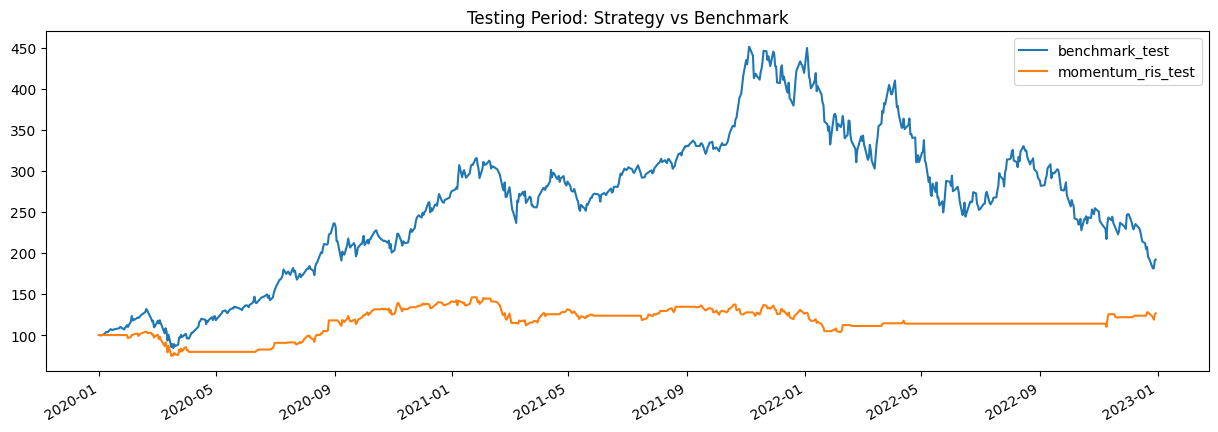

In [ ]:
# Direct comparison — Testing Period: Strategy vs Benchmark vs SPY
res_test_comparison = bt.run(benchmark_bt_test, backtest_test)
res_test_comparison.display()

ax = res_test_comparison.plot(title='Testing Period: Strategy vs Benchmark')

# Overlay SPY for market context
spy_test = spy.loc[test_start:test_end]
spy_norm  = spy_test / spy_test.iloc[0] * 100
ax.plot(spy_norm, label='SPY', color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
ax.legend()
plt.tight_layout()
plt.show()

#Heatmap

In [ ]:
# Parameter sensitivity heatmap
# Tests 6 momentum windows x 6 RSI windows = 36 combinations

momentum_vals = [32, 63, 126, 252, 504, 1008]
rsi_vals      = [1, 7, 14, 21, 28, 35]
tickers       = list(train_data.columns)
transaction_cost = 0.001

# Define RSI function once outside the loop (not 36 times inside it)
def rsi_calc2(price, n):
    delta    = price.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# Collect rows as a list, then build DataFrame once (replaces deprecated _append)
rows = []

for m in momentum_vals:
    for r in rsi_vals:
        # Momentum
        momentum2 = {}
        for ticker in tickers:
            s = (train_data[ticker] / train_data[ticker].shift(m) - 1) * 100
            momentum2[ticker] = s.dropna()
        momentum_df = pd.DataFrame(momentum2).reindex(train_data.index).fillna(0)

        # RSI
        rsi2_dict = {ticker: rsi_calc2(train_data[ticker], n=r) for ticker in tickers}
        rsi_df    = pd.DataFrame(rsi2_dict).reindex(train_data.index).fillna(50)

        # Signals
        buy  = (momentum_df >= momentum_df.mean()) & (rsi_df < rsi_df.mean())
        sell = (momentum_df < (momentum_df.mean() * -1)) & (rsi_df > 60)

        # Weights
        weights = pd.DataFrame(0.0, index=train_data.index, columns=tickers)
        for date in train_data.index:
            buys_today  = buy.loc[date]
            sells_today = sell.loc[date]
            selected = [t for t in tickers if buys_today[t] and not sells_today[t]]
            if selected:
                mag = 1 / len(selected)
                for t in selected:
                    weights.loc[date, t] = mag

        # Backtest
        strat_name = f"m{m}_r{r}"
        strat      = bt.Strategy(strat_name, [bt.algos.WeighTarget(weights), bt.algos.Rebalance()])
        backtest   = bt.Backtest(strat, train_data)
        res        = bt.run(backtest)

        stats = res[0].stats
        rows.append({
            'momentum_days': m,
            'rsi_days':      r,
            'CAGR':          stats['cagr'],
            'Sharpe':        stats['daily_sharpe']
        })

# Build DataFrame from list — no deprecated _append needed
reaction = pd.DataFrame(rows)

100%|██████████| 1/1 [00:00<00:00,  1.17it/s]
<ipython-input-88-a0c52e49ff21>:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reaction = reaction._append({
100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


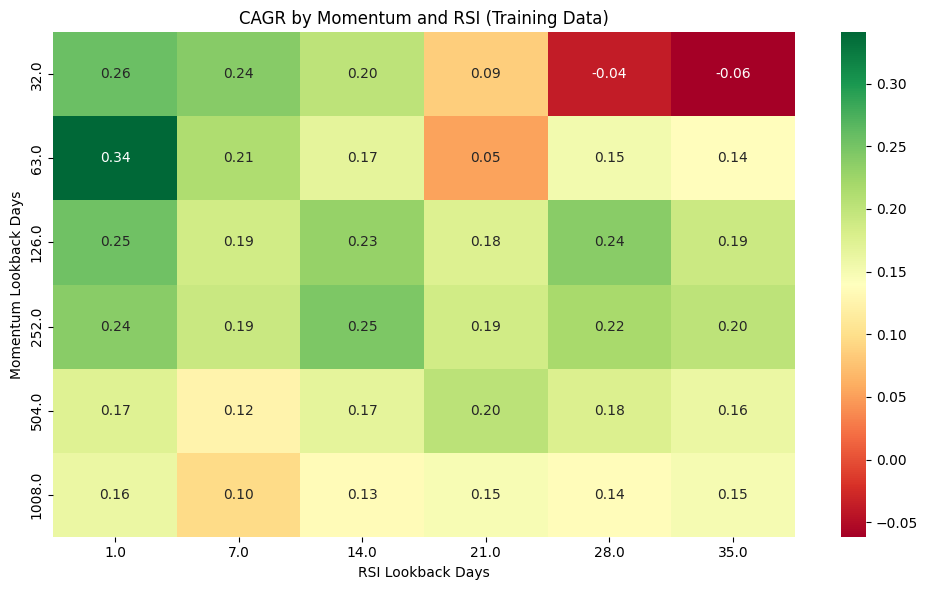

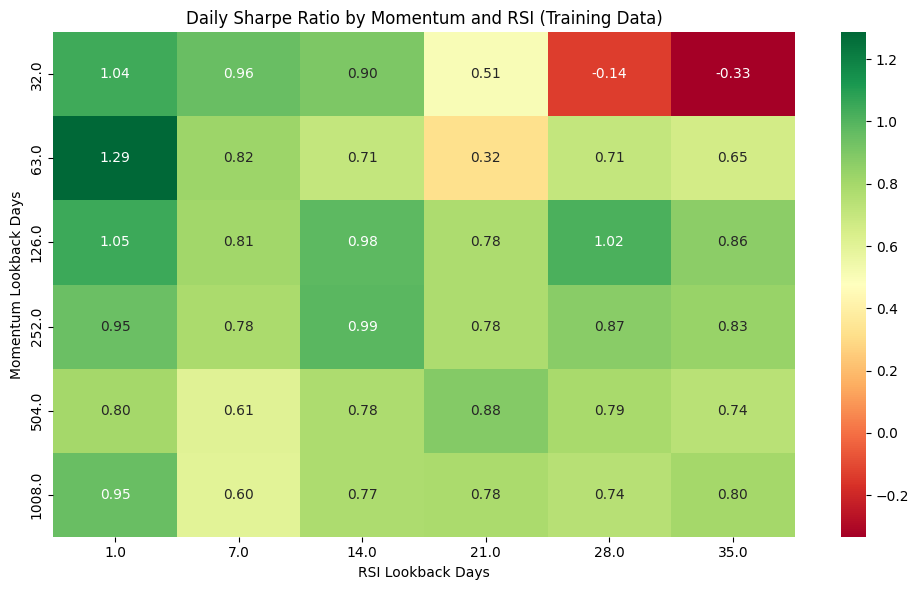

In [ ]:
# Pivot tables for heatmap

reaction_pivot_cagr = reaction.pivot(index='momentum_days', columns='rsi_days', values='CAGR')
reaction_pivot_sharpe = reaction.pivot(index='momentum_days', columns='rsi_days', values='Sharpe')

# CAGR Heatmap (Training)
plt.figure(figsize=(10, 6))
sb.heatmap(reaction_pivot_cagr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("CAGR by Momentum and RSI (Training Data)")
plt.xlabel("RSI Lookback Days")
plt.ylabel("Momentum Lookback Days")
plt.tight_layout()
plt.show()

# Sharpe Ratio Heatmap (Training)
plt.figure(figsize=(10, 6))
sb.heatmap(reaction_pivot_sharpe, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Daily Sharpe Ratio by Momentum and RSI (Training Data)")
plt.xlabel("RSI Lookback Days")
plt.ylabel("Momentum Lookback Days")
plt.tight_layout()
plt.show()


# Efficient Frontier Line

## Simple Efficient Frontier Line

In [ ]:
# Use only training data
clean_train_data = train_data.dropna()  # Ensure no NaNs
returns_train = clean_train_data.pct_change().dropna()

# Estimate expected returns and covariance matrix from training data
mu_train = expected_returns.mean_historical_return(clean_train_data)
cov_train = risk_models.sample_cov(clean_train_data)

# Efficient Frontier using training data
ef_train = EfficientFrontier(mu_train, cov_train)

In [ ]:
# Copy the Efficient Frontier object created from training data
ef_cp = ef_train.deepcopy()
ef_tangent = ef_train.deepcopy()

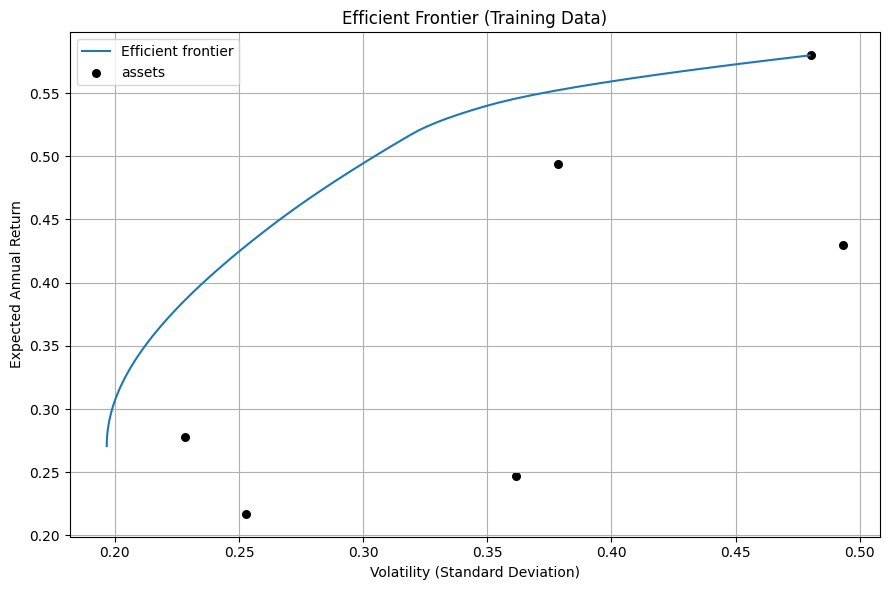

In [ ]:
# Plot efficient frontier for training data

fig, ax = plt.subplots(figsize=(9, 6))
plotting.plot_efficient_frontier(ef_train, ax=ax, show_assets=True)
plt.title("Efficient Frontier (Training Data)")
plt.xlabel("Volatility (Standard Deviation)")
plt.ylabel("Expected Annual Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Optimization for maximum Sharpe ratio using training data
ef_tangent.max_sharpe()

# Portfolio performance
ret_tangent, std_tangent, _ = ef_tangent.portfolio_performance(verbose=True)

# Cleaned asset weights
tangent_weights = ef_tangent.clean_weights()
print("Tangent Portfolio Weights (Training Data):")
print(tangent_weights)

Expected annual return: 41.3%
Annual volatility: 24.3%
Sharpe Ratio: 1.70
Tangent Portfolio Weights (Training Data):
OrderedDict([('aapl', 0.0724), ('nvda', 0.27942), ('msft', 0.32443), ('tsla', 0.09734), ('nflx', 0.21502), ('meta', 0.01139)])


In [ ]:
# Generate 10,000 random portfolios using training-period efficient frontier
n_samples = 10000
w = np.random.dirichlet(np.ones(ef_cp.n_assets), n_samples)

# Expected returns and standard deviations
rets = w.dot(ef_cp.expected_returns)
stds = np.sqrt(np.diag(w @ ef_cp.cov_matrix @ w.T))

# Sharpe ratios
sharpes = rets / stds
sharpes

array([1.43314168, 1.49605655, 1.40189833, ..., 1.54442585, 1.40544991,
       1.52840231])

In [ ]:
# Use returns from training period only
hrp = HRPOpt(returns_train)

# Optimize for Hierarchical Risk Parity portfolio
hrp_weights = hrp.optimize()

# Show weights
print("HRP Portfolio Weights (Training Data):")
print(hrp_weights)

HRP Portfolio Weights (Training Data):
OrderedDict([('aapl', np.float64(0.23646303461529833)), ('meta', np.float64(0.14386758840906258)), ('msft', np.float64(0.2905869576220928)), ('nflx', np.float64(0.08164287552901721)), ('nvda', np.float64(0.1520816376916548)), ('tsla', np.float64(0.09535790613287425))])


In [ ]:
# Expected performance of the HRP (low-risk) portfolio based on training data

ret_hrp, std_hrp, _ = hrp.portfolio_performance(verbose=True)

Expected annual return: 33.8%
Annual volatility: 20.9%
Sharpe Ratio: 1.61


Sharpe is between 1.67 and 1.35 depending on the risk acquired

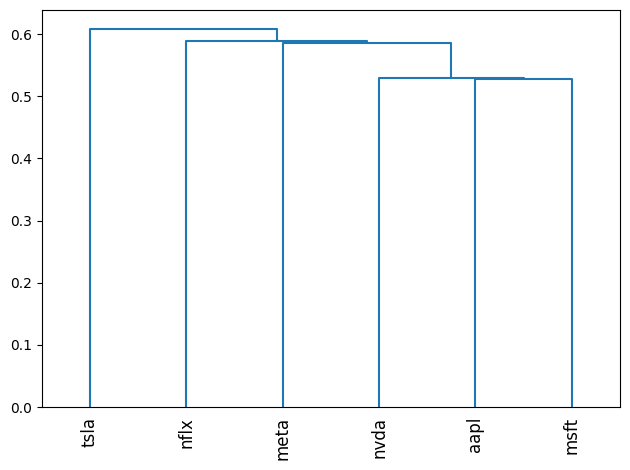

<Axes: >

In [ ]:
# Plot correlation-based hierarchical clustering dendrogram (Training Data)

plotting.plot_dendrogram(hrp, showfig=True)

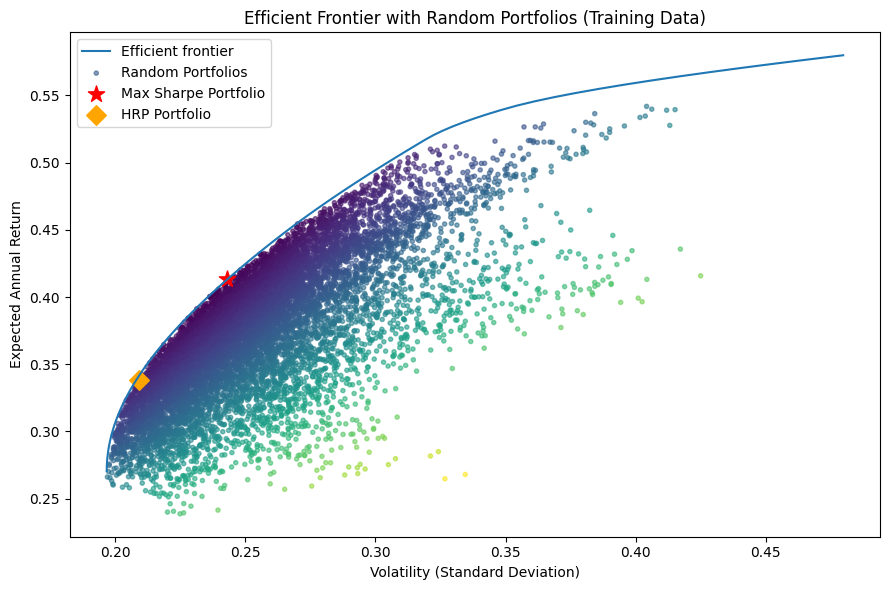

In [ ]:
# Plotting the efficient frontier line
fig, ax = plt.subplots(figsize=(9, 6))

# Efficient Frontier from training data
plotting.plot_efficient_frontier(ef_cp, ax=ax, show_assets=False)

# Simulated random portfolios
ax.scatter(stds, rets, marker=".", c=sharpes, cmap="viridis_r", alpha=0.6, label="Random Portfolios")

# Tangent portfolio (Max Sharpe)
ax.scatter(std_tangent, ret_tangent, marker="*", s=150, c="red", label="Max Sharpe Portfolio")

# HRP portfolio (Low-risk)
ax.scatter(std_hrp, ret_hrp, marker="D", s=100, c="orange", label="HRP Portfolio")

# Titles and Labels
ax.set_title("Efficient Frontier with Random Portfolios (Training Data)")
ax.set_xlabel("Volatility (Standard Deviation)")
ax.set_ylabel("Expected Annual Return")
ax.legend()
plt.tight_layout()
plt.show()

To combine the strategy proposed with the efficient frontier line the following code is required

##Combination of Strategy Proposed and Efficient Frontier Line

In [ ]:
# Filter and normalize weights from training-period strategy

filtered_weights = target_weights_train[target_weights_train.sum(axis=1) != 0]
normalized_weights = filtered_weights.div(filtered_weights.sum(axis=1), axis=0)

# Combine strategy: mean of normalized momentum + RSI weights
mr_weights = normalized_weights.mean().reindex(clean_train_data.columns).fillna(0)

# Calculate expected return and risk from training-period parameters
mr_return = np.dot(mr_weights.values, mu_train.values)
mr_risk = np.sqrt(np.dot(mr_weights.values.T, np.dot(cov_train.values, mr_weights.values)))

print("Combined Strategy Expected Return (Training):", round(mr_return, 4))
print("Combined Strategy Risk (Std Dev, Training):", round(mr_risk, 4))


Combined Strategy Expected Return (Training): 0.3296
Combined Strategy Risk (Std Dev, Training): 0.21


In [ ]:
# Final print for clarity with context (Training Data)
print("Expected Annual Return of Momentum + RSI Strategy (Training):", round(mr_return, 4))
print("Annualized Risk (Std Dev) of Momentum + RSI Strategy (Training):", round(mr_risk, 4))

Expected Annual Return of Momentum + RSI Strategy (Training): 0.3296
Annualized Risk (Std Dev) of Momentum + RSI Strategy (Training): 0.21


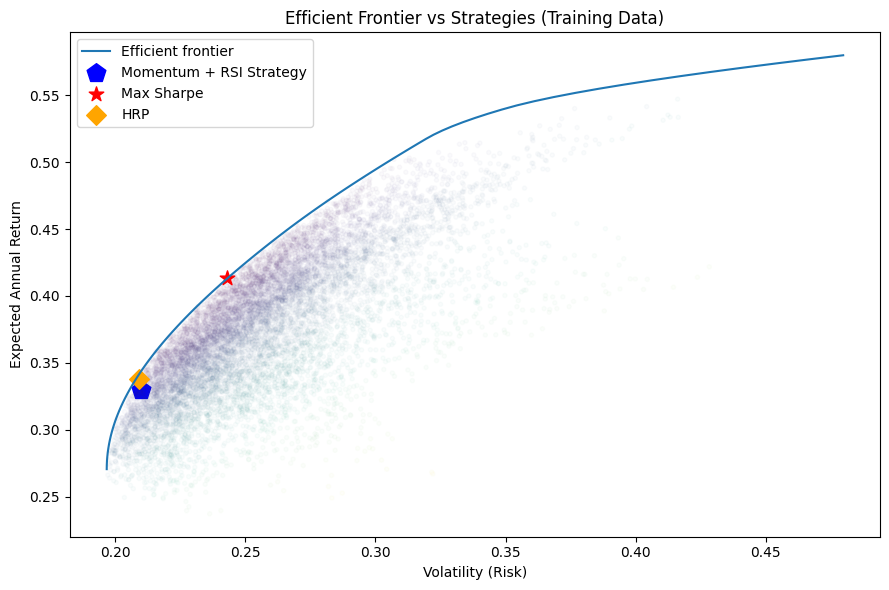

In [ ]:
# Recreate efficient frontier using training-period inputs to avoid PyPortfolioOpt context errors
ef_clean = EfficientFrontier(mu_train, cov_train)

# Plot Efficient Frontier with strategy comparison (Training Data)
fig, ax = plt.subplots(figsize=(9, 6))
plotting.plot_efficient_frontier(ef_clean, ax=ax, show_assets=False)

# Strategy: Momentum + RSI (Training)
ax.scatter(mr_risk, mr_return, marker="p", s=200, c="blue", label="Momentum + RSI Strategy")

# Random Portfolios (Training)
ax.scatter(stds, rets, marker=".", c=sharpes, cmap="viridis_r", alpha=0.025)

# Tangent Portfolio (Max Sharpe)
ax.scatter(std_tangent, ret_tangent, marker="*", s=120, c="red", label="Max Sharpe")

# HRP Portfolio
ax.scatter(std_hrp, ret_hrp, marker="D", s=100, c="orange", label="HRP")

# Labels and aesthetics
ax.set_title("Efficient Frontier vs Strategies (Training Data)")
ax.set_xlabel("Volatility (Risk)")
ax.set_ylabel("Expected Annual Return")
ax.legend()
plt.tight_layout()
plt.show()

Check the results

In [ ]:
print("==== Momentum + RSI Strategy (Training Data) ====\n")

# Annualized Return
print("Expected Annualized Return (%):")
print(round(mr_return * 100, 2))

# Annualized Volatility (Risk)
print("\nExpected Annualized Volatility (%):")
print(round(mr_risk * 100, 2))

# Weights for Proposed Strategy
print("\nAsset Weights (%):")
print((mr_weights * 100).round(2))

# Check Sum of Weights
print("\nSum of Weights (%):")
print(round(mr_weights.sum() * 100, 2))

==== Momentum + RSI Strategy (Training Data) ====

Expected Annualized Return (%):
32.96

Expected Annualized Volatility (%):
21.0

Asset Weights (%):
aapl    25.60
nvda    12.53
msft    25.68
tsla     7.72
nflx    11.18
meta    17.28
dtype: float64

Sum of Weights (%):
100.0


## Results Summary

In [ ]:
# ── Final Results Summary ────────────────────────────────────────────────────
print("=" * 52)
print("   RSI + MOMENTUM STRATEGY  —  RESULTS SUMMARY")
print("=" * 52)

def display_period(label, res, strategy_key, benchmark_key):
    s_stats = res[strategy_key].stats
    b_stats = res[benchmark_key].stats
    print(f"\n{'─'*52}")
    print(f"  {label}")
    print(f"{'─'*52}")
    print(f"  {'Metric':<22} {'Strategy':>12} {'Benchmark':>12}")
    print(f"  {'─'*46}")
    metrics = [
        ('CAGR (%)',        'cagr',          100),
        ('Sharpe Ratio',    'daily_sharpe',    1),
        ('Max Drawdown (%)', 'max_drawdown',  100),
        ('Volatility (%)',  'daily_vol',      100),
    ]
    for name, key, scale in metrics:
        sv = s_stats.get(key, float('nan'))
        bv = b_stats.get(key, float('nan'))
        sv_str = f"{sv * scale:>11.2f}" if sv == sv else "         n/a"
        bv_str = f"{bv * scale:>11.2f}" if bv == bv else "         n/a"
        print(f"  {name:<22} {sv_str} {bv_str}")

display_period(
    "TRAINING PERIOD  (May 2012 – Dec 2019)",
    res_train_comparison, 'momentum_ris_train', 'benchmark_train'
)
display_period(
    "TESTING PERIOD   (Jan 2020 – Jan 2023)",
    res_test_comparison,  'momentum_ris_test',  'benchmark_test'
)

print(f"\n{'─'*52}")
print(f"  EFFICIENT FRONTIER  (Training Data)")
print(f"{'─'*52}")
print(f"  {'Portfolio':<28} {'Return %':>8} {'Risk %':>8}")
print(f"  {'─'*46}")
print(f"  {'Max Sharpe':<28} {ret_tangent*100:>8.2f} {std_tangent*100:>8.2f}")
print(f"  {'HRP (Hierarchical Risk Parity)':<28} {ret_hrp*100:>8.2f} {std_hrp*100:>8.2f}")
print(f"  {'Momentum + RSI Strategy':<28} {mr_return*100:>8.2f} {mr_risk*100:>8.2f}")
print("=" * 52)